In [2]:
!pip install transformers datasets torch errant spacy pyyaml numpy python-dotenv langchain-groq tqdm nltk
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 11.9 MB/s  0:00:01 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Step 2 — Imports and Configuration

Load all libraries and define the pipeline parameters.

- Generation model: LLaMA 3.1 via Groq API
- Task models: T5, Grammar Error Correcter v1, Fine-tuned BERT

In [ ]:
import os
import random
import json
import numpy as np
from tqdm.auto import tqdm
from dotenv import load_dotenv

# Load API key from environment 
os.environ["GROQ_API_KEY"] = "GROQ_API_KEY_HERE"  

# Pipeline configuration 
CONFIG = {
    "dataset": {
        "name": "liweili/c4_200m",
        "split": "train",
        "sample_size": 50,        # how many real sentences to load
    },
    "generation": {
        "model": "llama-3.1-8b-instant",   # generator LLM (must differ from task models)
        "temperature": 0.5,                 # above 0 ensures variance (per paper)
        "num_runs": 3,                      # repeat N times → report mean ± std
        "sample_size": 20,                  # synthetic sentences per run
        "error_types": [
            "subject-verb disagreement",
            "wrong tense",
            "missing article",
            "spelling mistake",
            "wrong preposition"
        ],
    },
    "task_models": [
        {"name": "vennify/t5-base-grammar-correction",      "type": "t5"},
        {"name": "prithivida/grammar_error_correcter_v1",   "type": "gec_v1"},
    ],
}

print(" Configuration loaded.")
print(f"   Dataset     : {CONFIG['dataset']['name']}")
print(f"   Generator   : {CONFIG['generation']['model']}")
print(f"   Num runs    : {CONFIG['generation']['num_runs']}")
print(f"   Task models : {[m['name'] for m in CONFIG['task_models']]}")

 Configuration loaded.
   Dataset     : liweili/c4_200m
   Generator   : llama-3.1-8b-instant
   Num runs    : 3
   Task models : ['vennify/t5-base-grammar-correction', 'prithivida/grammar_error_correcter_v1']


## Step 3 — Load Real GEC Dataset

Load correct sentences from the C4 200M GEC dataset.
These sentences are used as source material for the generator.
They only guide the generation.

In [5]:
from datasets import load_dataset

def load_gec_dataset(config):
    """Load real GEC sentences from HuggingFace GEC dataset."""
    print(f"Loading dataset: agentlans/grammar-correction ...")
    dataset = load_dataset("agentlans/grammar-correction", split="train")
    
    samples = []
    for i in range(config["dataset"]["sample_size"]):
        row = dataset[i]
        samples.append({
            "incorrect": row["input"],
            "correct":   row["output"]
        })
    
    print(f"Loaded {len(samples)} samples.")
    return samples

real_data = load_gec_dataset(CONFIG)

# Preview
print("\nSample preview:")
for s in real_data[:3]:
    print(f"  INCORRECT: {s['incorrect'][:80]}")
    print(f"  CORRECT  : {s['correct'][:80]}")
    print()

Loading dataset: agentlans/grammar-correction ...


Generating validation split: 100%|██████████| 25000/25000 [00:00<00:00, 404007.03 examples/s]

Loaded 50 samples.

Sample preview:
  INCORRECT: The Kānvar is a travel, made by devotees of Shiva, known as Kānvarias of Hindu p
  CORRECT  : The Kānvar is a travel, undertaken by devotees of Shiva, which are known as Kānv

  INCORRECT: How Long Doo You Have to Go To Schools To Be Biochemist?
  CORRECT  : How Long Do You Have to Go to School to Be a Biochemist?

  INCORRECT: DVHS is the replacement for consumer VHS it will have no analog inputs or output
  CORRECT  : D-VHS is the replacement for consumer VHS. It will have no analog inputs or outp



## Step 4 — Synthetic Data Generator (GENERATE phase)

The LLM receives a correct sentence and is asked to introduce exactly one grammatical error of a specific type. The result is a synthetic (incorrect, correct) pair with known ground truth.

In [7]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Initialize the generator LLM
generator_llm = ChatGroq(
    model=CONFIG["generation"]["model"],
    temperature=CONFIG["generation"]["temperature"],
    api_key=os.environ["GROQ_API_KEY"]
)

# Prompt template
prompt = PromptTemplate.from_template(
    """You are a grammar error generator for NLP research.
Given a correct English sentence, introduce exactly one grammatical error of type: {error_type}
Return ONLY the corrupted sentence. No explanation, no punctuation changes unless required.

Correct sentence: {sentence}
Corrupted sentence:"""
)

chain = prompt | generator_llm | StrOutputParser()

def generate_synthetic_data(real_samples, config):
    """Generate synthetic corrupted sentences using LLM."""
    synthetic = []
    sample = real_samples[:config["generation"]["sample_size"]]

    for item in tqdm(sample, desc="Generating synthetic data"):
        error_type = random.choice(config["generation"]["error_types"])
        try:
            corrupted = chain.invoke({
                "sentence":   item["correct"],
                "error_type": error_type
            }).strip()
            synthetic.append({
                "original":   item["correct"],   # ground truth (what correction should be)
                "corrupted":  corrupted,          # what the task model receives as input
                "error_type": error_type
            })
        except Exception as e:
            print(f"[WARN] Generation failed: {e}")

    print(f"Generated {len(synthetic)} synthetic samples.")
    return synthetic

# Test with a small batch first
test_data = generate_synthetic_data(real_data, CONFIG)

# Preview
print("\nSynthetic data preview:")
for s in test_data[:3]:
    print(f"  ORIGINAL (ground truth) : {s['original'][:80]}")
    print(f"  CORRUPTED (model input) : {s['corrupted'][:80]}")
    print(f"  ERROR TYPE              : {s['error_type']}")
    print()

Generating synthetic data: 100%|██████████| 20/20 [00:02<00:00,  7.98it/s]

Generated 20 synthetic samples.

Synthetic data preview:
  ORIGINAL (ground truth) : The Kānvar is a travel, undertaken by devotees of Shiva, which are known as Kānv
  CORRUPTED (model input) : The Kānvar is a travel undertaken by devotees of Shiva, which are known as Kānva
  ERROR TYPE              : missing article

  ORIGINAL (ground truth) : How Long Do You Have to Go to School to Be a Biochemist?
  CORRUPTED (model input) : How long do you guys have to go to school to be a biochemist?
  ERROR TYPE              : subject-verb disagreement

  ORIGINAL (ground truth) : D-VHS is the replacement for consumer VHS. It will have no analog inputs or outp
  CORRUPTED (model input) : D-VHS is the replacement for consumer VHS. It will have no analog inputs or outp
  ERROR TYPE              : wrong preposition



## Step 5 — Verifier

Before evaluating, we verify the generated data quality.
A generated sample is discarded if:
- The corrupted sentence is identical to the original (LLM failed to introduce an error)
- The sentence is too short to be meaningful
So, this ensures we only evaluate on valid test cases.

In [8]:
def verify_synthetic_data(synthetic_data):
    """Filter out bad generations."""
    verified = []
    for item in synthetic_data:
        if not item["corrupted"] or not item["original"]:
            continue
        if item["corrupted"].strip() == item["original"].strip():
            print(f"[SKIP] LLM returned unchanged sentence: {item['original'][:60]}")
            continue
        if len(item["corrupted"].split()) < 3:
            print(f"[SKIP] Too short: {item['corrupted']}")
            continue
        verified.append(item)

    print(f"Verified: {len(verified)}/{len(synthetic_data)} samples passed.")
    return verified

test_data = verify_synthetic_data(test_data)

Verified: 20/20 samples passed.


## Step 6 — Load Task Models (EVALUATE phase)

Load the GEC models that will be evaluated.
We test how well models can correct the grammar errors in our synthetic sentences.

Models:
- **T5** 
- **Grammar Error Correcter v1** 

In [9]:
import torch
from transformers import (
    T5ForConditionalGeneration, T5Tokenizer,
    AutoTokenizer, AutoModelForSeq2SeqLM
)

print("Loading task models (this may take a minute)...")

# Model 1: T5
t5_tokenizer = T5Tokenizer.from_pretrained("vennify/t5-base-grammar-correction")
t5_model     = T5ForConditionalGeneration.from_pretrained("vennify/t5-base-grammar-correction")
t5_model.eval()
print("T5 loaded.")

# Model 2: Grammar Error Correcter v1
gec_tokenizer = AutoTokenizer.from_pretrained("prithivida/grammar_error_correcter_v1")
gec_model     = AutoModelForSeq2SeqLM.from_pretrained("prithivida/grammar_error_correcter_v1")
gec_model.eval()
print("Grammar Error Correcter v1 loaded.")

def run_t5(sentences):
    results = []
    for s in sentences:
        inputs = t5_tokenizer.encode(
            "grammar: " + s, return_tensors="pt", max_length=128, truncation=True
        )
        with torch.no_grad():
            out = t5_model.generate(inputs, num_beams=5, max_length=128)
        results.append(t5_tokenizer.decode(out[0], skip_special_tokens=True))
    return results

def run_gec_v1(sentences):
    results = []
    for s in sentences:
        inputs = gec_tokenizer.encode(
            "gec: " + s, return_tensors="pt", max_length=128, truncation=True
        )
        with torch.no_grad():
            out = gec_model.generate(inputs, do_sample=True, num_beams=7, max_length=128)
        results.append(gec_tokenizer.decode(out[0], skip_special_tokens=True))
    return results

print("\n All task models ready.")

Loading task models (this may take a minute)...


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 58529.36it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


T5 loaded.


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 62680.71it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/Users/beyzaunlu/pythonbeyza/.venv/lib/python3.14/site-pac

Grammar Error Correcter v1 loaded.

 All task models ready.


## Step 7 — Metrics

We use two evaluation metrics:

- **GLEU** — measures fluency of the correction (higher = better)
- **ERRANT** — measures how accurately the model identified and fixed
  the right type of error (precision, recall, F0.5)

F0.5 weights precision twice as much as recall, which is standard in GEC.

In [10]:
import errant
import nltk
nltk.download("punkt", quiet=True)
from nltk.translate.gleu_score import sentence_gleu

annotator = errant.load("en")

def compute_gleu(results):
    """Compute average GLEU score across all samples."""
    scores = [
        sentence_gleu([item["original"].split()], item["prediction"].split())
        for item in results
    ]
    return round(float(np.mean(scores)), 4)

def compute_errant(results):
    """Compute ERRANT precision, recall, F0.5."""
    tp = fp = fn = 0
    for item in results:
        orig = annotator.parse(item["corrupted"])
        ref  = annotator.parse(item["original"])
        pred = annotator.parse(item["prediction"])

        ref_edits  = annotator.annotate(orig, ref)
        pred_edits = annotator.annotate(orig, pred)

        ref_set  = {(e.o_start, e.o_end, e.type) for e in ref_edits}
        pred_set = {(e.o_start, e.o_end, e.type) for e in pred_edits}

        tp += len(pred_set & ref_set)
        fp += len(pred_set - ref_set)
        fn += len(ref_set - pred_set)

    p   = tp / (tp + fp) if (tp + fp) > 0 else 0
    r   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f05 = (1.25 * p * r) / (0.25 * p + r) if (p + r) > 0 else 0
    return {"precision": round(p,4), "recall": round(r,4), "f0.5": round(f05,4)}

print(" Metrics ready.")

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>


 Metrics ready.


## Step 8 — Full GET Pipeline with N Runs

This is the complete pipeline loop.

Following the paper's methodology, we run the pipeline **N times**,
each time generating a fresh batch of synthetic data.
This allows us to compute mean ± standard deviation across runs,
which reveals how stable each model really is on unseen data.

a high std means the model is unreliable on truly unseen data.

In [ ]:
def run_pipeline(config, real_data):
    """Full GET pipeline: Generate → Evaluate → Trash × N runs."""

    all_run_scores = []
    num_runs = config["generation"]["num_runs"]

    for run_idx in range(num_runs):
        print(f"\n{'='*50}")
        print(f"RUN {run_idx + 1} / {num_runs}")
        print(f"{'='*50}")

        # ── GENERATE ──────────────────────────────────
        synthetic = generate_synthetic_data(real_data, config)
        synthetic = verify_synthetic_data(synthetic)
        corrupted_sentences = [item["corrupted"] for item in synthetic]

        # ── EVALUATE ──────────────────────────────────
        run_scores = {}

        # T5
        print("\nRunning T5...")
        t5_predictions = run_t5(corrupted_sentences)
        t5_results = [{**item, "prediction": pred}
                      for item, pred in zip(synthetic, t5_predictions)]
        run_scores["T5"] = {
            "gleu":   compute_gleu(t5_results),
            "errant": compute_errant(t5_results)
        }
        print(f"  T5 GLEU: {run_scores['T5']['gleu']}")
        print(f"  T5 ERRANT F0.5: {run_scores['T5']['errant']['f0.5']}")

        # GEC v1
        print("\nRunning Grammar Error Correcter v1...")
        gec_predictions = run_gec_v1(corrupted_sentences)
        gec_results = [{**item, "prediction": pred}
                       for item, pred in zip(synthetic, gec_predictions)]
        run_scores["GEC_v1"] = {
            "gleu":   compute_gleu(gec_results),
            "errant": compute_errant(gec_results)
        }
        print(f"  GEC_v1 GLEU: {run_scores['GEC_v1']['gleu']}")
        print(f"  GEC_v1 ERRANT F0.5: {run_scores['GEC_v1']['errant']['f0.5']}")

        all_run_scores.append(run_scores)

        # ── TRASH ─────────────────────────────────────
        synthetic.clear()
        print("\n Synthetic data trashed.")

    return all_run_scores

# Run the full pipeline
all_scores = run_pipeline(CONFIG, real_data)
print("\n Pipeline complete!")


RUN 1 / 3


Generating synthetic data: 100%|██████████| 20/20 [00:02<00:00,  8.43it/s]


Generated 20 synthetic samples.
Verified: 20/20 samples passed.

Running T5...
  T5 GLEU: 0.7662
  T5 ERRANT F0.5: 0.2703

Running Grammar Error Correcter v1...
  GEC_v1 GLEU: 0.7644
  GEC_v1 ERRANT F0.5: 0.2672

🗑️  Synthetic data trashed.

RUN 2 / 3


Generating synthetic data: 100%|██████████| 20/20 [00:02<00:00,  8.66it/s]


Generated 20 synthetic samples.
[SKIP] LLM returned unchanged sentence: In turn, it is through growing up with Edward that my other 
Verified: 19/20 samples passed.

Running T5...
  T5 GLEU: 0.7121
  T5 ERRANT F0.5: 0.365

Running Grammar Error Correcter v1...
  GEC_v1 GLEU: 0.6835
  GEC_v1 ERRANT F0.5: 0.3719

🗑️  Synthetic data trashed.

RUN 3 / 3


Generating synthetic data: 100%|██████████| 20/20 [00:02<00:00,  7.89it/s]


Generated 20 synthetic samples.
Verified: 20/20 samples passed.

Running T5...
  T5 GLEU: 0.7401
  T5 ERRANT F0.5: 0.2155

Running Grammar Error Correcter v1...
  GEC_v1 GLEU: 0.7378
  GEC_v1 ERRANT F0.5: 0.2232

🗑️  Synthetic data trashed.

 Pipeline complete!


## Step 9 — Aggregate Results (Mean ± Std)

Aggregate scores across all N runs.
Reporting mean ± standard deviation is the key contribution of this approach. It shows not just average performance, but how consistenteach model is when evaluated on fresh, unseen data each time.

In [12]:
def aggregate_results(all_run_scores):
    """Compute mean ± std across N runs for each model and metric."""
    final = {}
    for model_name in all_run_scores[0]:
        final[model_name] = {}

        # GLEU
        gleu_values = [run[model_name]["gleu"] for run in all_run_scores]
        final[model_name]["gleu"] = {
            "mean": round(float(np.mean(gleu_values)), 4),
            "std":  round(float(np.std(gleu_values)),  4)
        }

        # ERRANT
        final[model_name]["errant"] = {}
        for sub in ["precision", "recall", "f0.5"]:
            values = [run[model_name]["errant"][sub] for run in all_run_scores]
            final[model_name]["errant"][sub] = {
                "mean": round(float(np.mean(values)), 4),
                "std":  round(float(np.std(values)),  4)
            }

    return final

final_results = aggregate_results(all_scores)

print("=" * 55)
print("FINAL RESULTS (mean ± std across runs)")
print("=" * 55)
for model, metrics in final_results.items():
    print(f"\n{model}:")
    g = metrics["gleu"]
    print(f"  GLEU         : {g['mean']} ± {g['std']}")
    e = metrics["errant"]
    print(f"  ERRANT P     : {e['precision']['mean']} ± {e['precision']['std']}")
    print(f"  ERRANT R     : {e['recall']['mean']} ± {e['recall']['std']}")
    print(f"  ERRANT F0.5  : {e['f0.5']['mean']} ± {e['f0.5']['std']}")

FINAL RESULTS (mean ± std across runs)

T5:
  GLEU         : 0.7395 ± 0.0221
  ERRANT P     : 0.3119 ± 0.064
  ERRANT R     : 0.2105 ± 0.0543
  ERRANT F0.5  : 0.2836 ± 0.0618

GEC_v1:
  GLEU         : 0.7286 ± 0.0337
  ERRANT P     : 0.3203 ± 0.0766
  ERRANT R     : 0.2138 ± 0.0534
  ERRANT F0.5  : 0.2874 ± 0.0624


## Results

### GLEU Scores
Both models perform similarly in terms of fluency correction:
- **T5** achieves a mean GLEU of **0.7395 ± 0.0221**
- **GEC_v1** achieves a mean GLEU of **0.7286 ± 0.0337**

T5 scores a little higher on GLEU, suggesting it produces corrections
that are closer to the reference sentence in terms of word overlap.
GEC_v1 shows a higher standard deviation, meaning
its fluency performance is less stable across runs.

### ERRANT Scores (Precision, Recall, F0.5)
Both models show moderate precision but low recall:
- **T5** F0.5: **0.2836 ± 0.0618**
- **GEC_v1** F0.5: **0.2874 ± 0.0624**

The scores are nearly identical, with GEC_v1 having a very slight edge
in F0.5. However, the high standard deviations (±0.06) on both models
indicate that performance varies considerably across runs,
neither model is highly reliable on truly unseen synthetic data.

The low recall values for both suggest that both models
frequently miss errors, even when they detect some correctly.

The model may have already "seen" that data during training. So it gets a high score, but not because it's actually smart. It just memorized the answers.
In our pipeline, we generate brand new sentences every run. The model has never seen them before. So the score we get is honest.
The ± number (standard deviation) is the key. It tells us: "if we test again with different sentences, how much does the score change?"

Small ± → model is consistent, we can trust it
Big ± → model gets lucky sometimes, not reliable

Both T5 and GEC_v1 have ±0.06 on F0.5, which is quite high. This means their performance jumps around a lot depending on which sentences they see. On a fixed benchmark, you would never notice this problem.

Results saved to results.json


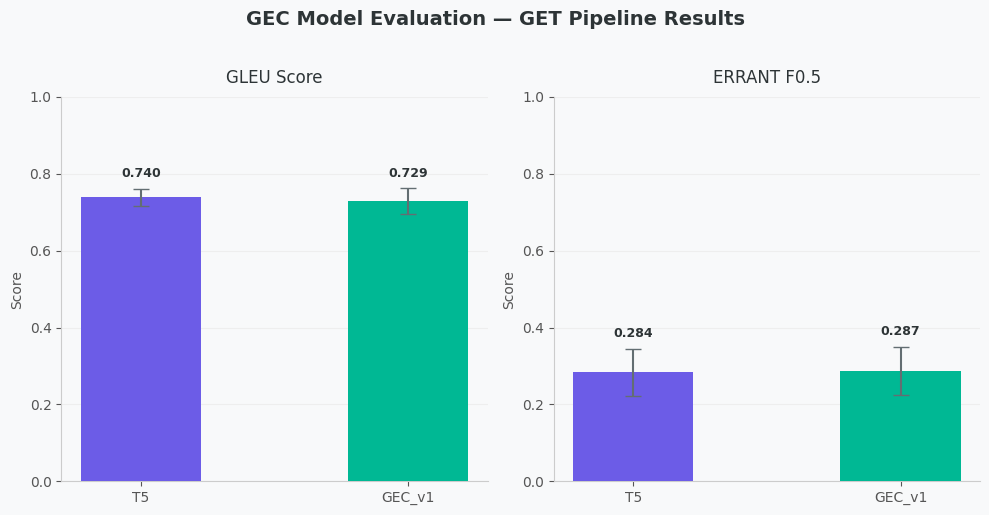

Chart saved to results_chart.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Save to JSON
with open("results.json", "w") as f:
    json.dump(final_results, f, indent=2)
print("Results saved to results.json")

# Colors
colors = {
    "T5":     "#6C5CE7",
    "GEC_v1": "#00B894",
}

models     = list(final_results.keys())
gleu_means = [final_results[m]["gleu"]["mean"] for m in models]
gleu_stds  = [final_results[m]["gleu"]["std"]  for m in models]
f05_means  = [final_results[m]["errant"]["f0.5"]["mean"] for m in models]
f05_stds   = [final_results[m]["errant"]["f0.5"]["std"]  for m in models]

x     = np.arange(len(models))
width = 0.45

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.tick_params(colors="#555555")
    ax.yaxis.grid(True, color="#EEEEEE", zorder=0)

fig.suptitle("GEC Model Evaluation — GET Pipeline Results",
             fontsize=14, fontweight="bold", color="#2D3436", y=1.02)

bar_colors = [colors[m] for m in models]

# Plot 1: GLEU
axes[0].bar(x, gleu_means, width, yerr=gleu_stds, capsize=6,
            color=bar_colors, zorder=3,
            error_kw={"ecolor": "#636E72", "lw": 1.5})
axes[0].set_title("GLEU Score", fontsize=12, color="#2D3436", pad=10)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=10)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score", color="#555555")
for i, (m, s) in enumerate(zip(gleu_means, gleu_stds)):
    axes[0].text(i, m + s + 0.03, f"{m:.3f}", ha="center",
                 fontsize=9, color="#2D3436", fontweight="bold")

# Plot 2: ERRANT F0.5
axes[1].bar(x, f05_means, width, yerr=f05_stds, capsize=6,
            color=bar_colors, zorder=3,
            error_kw={"ecolor": "#636E72", "lw": 1.5})
axes[1].set_title("ERRANT F0.5", fontsize=12, color="#2D3436", pad=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=10)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Score", color="#555555")
for i, (m, s) in enumerate(zip(f05_means, f05_stds)):
    axes[1].text(i, m + s + 0.03, f"{m:.3f}", ha="center",
                 fontsize=9, color="#2D3436", fontweight="bold")

plt.tight_layout()
plt.savefig("results_chart.png", dpi=150, bbox_inches="tight",
            facecolor="#F8F9FA")
plt.show()
print("Chart saved to results_chart.png")